In [1]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
# Globalny motyw — raz, na początku notebooka
sns.set_theme(style='whitegrid', palette='muted')
# Dataset tips — restauracja, 244 rachunki (znany z W09)
tips = sns.load_dataset('tips')
print(f"Tips dataset: {tips.shape[0]} wierszy × {tips.shape[1]} kolumn")
print(f"Kolumny: {list(tips.columns)}")
tips.head(3)


Tips dataset: 244 wierszy × 7 kolumn
Kolumny: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


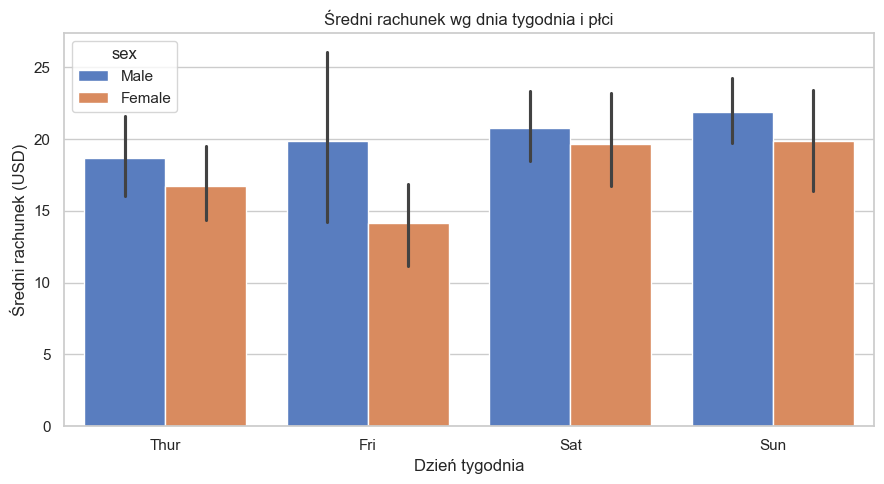

Zapisano: barplot_dzien_plec.png


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
 data=tips,
 x='day',
 y='total_bill',
 hue='sex',
 ax=ax,
 palette='muted',
 errorbar=('ci', 95), # 95% CI = przedział ufności średniej
)
ax.set_title('Średni rachunek wg dnia tygodnia i płci')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Średni rachunek (USD)')
plt.tight_layout()
plt.savefig('barplot_dzien_plec.png', dpi=150, bbox_inches='tight',
facecolor='white')
plt.show()
plt.close()
print("Zapisano: barplot_dzien_plec.png")


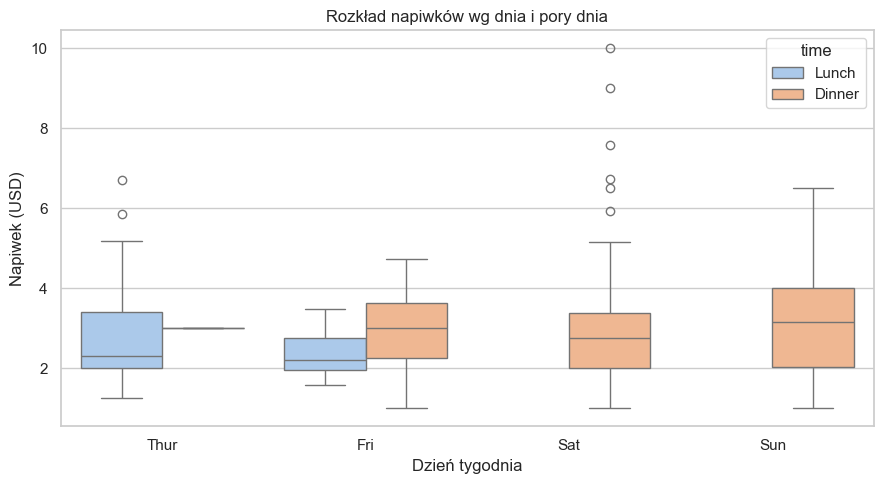

Zapisano: boxplot_napiwki.png


In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=tips,
    x='day',
    y='tip',
    hue='time',
    ax=ax,
    palette='pastel',
)
ax.set_title('Rozkład napiwków wg dnia i pory dnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Napiwek (USD)')
plt.tight_layout()
plt.savefig('boxplot_napiwki.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: boxplot_napiwki.png")

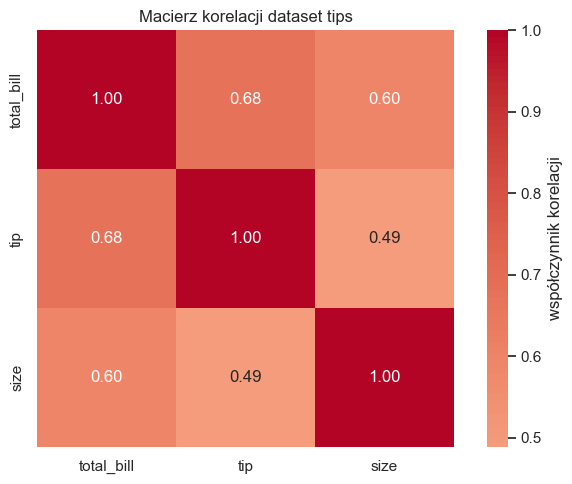

Zapisano: heatmap_korelacja.png


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = tips.select_dtypes('number').corr()
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax,
    square=True,
    cbar_kws={'label': 'współczynnik korelacji'},
)
ax.set_title('Macierz korelacji dataset tips')
plt.tight_layout()
plt.savefig('heatmap_korelacja.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: heatmap_korelacja.png")

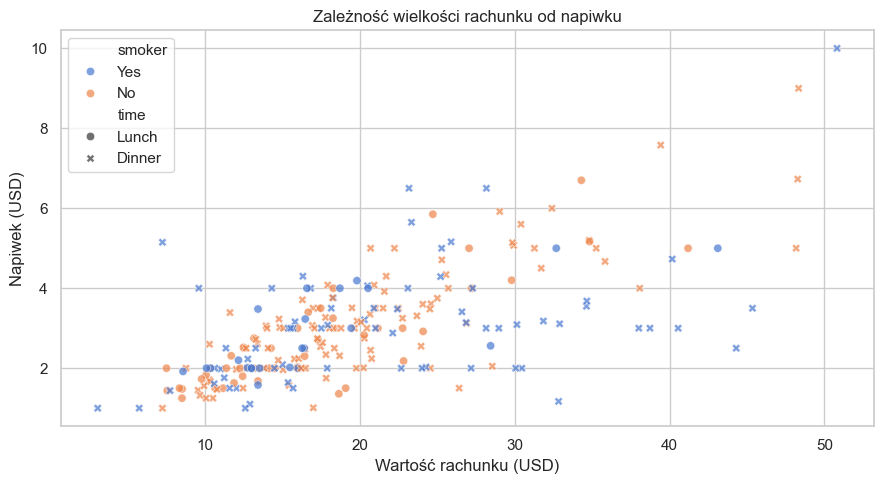

In [10]:
fig, ax = plt.subplots(figsize=(9, 5)) 
sns.scatterplot(
    data=tips,
    x='total_bill',
    y='tip',
    hue='smoker',
    style='time',
    alpha=0.7,
    ax=ax
) 
ax.set_title('Zależność wielkości rachunku od napiwku')
ax.set_xlabel('Wartość rachunku (USD)') 
ax.set_ylabel('Napiwek (USD)') 
plt.tight_layout() 
plt.savefig('scatter_rachunek_napiwek.png', dpi=150, bbox_inches='tight', facecolor='white') 
plt.show()
plt.close() 

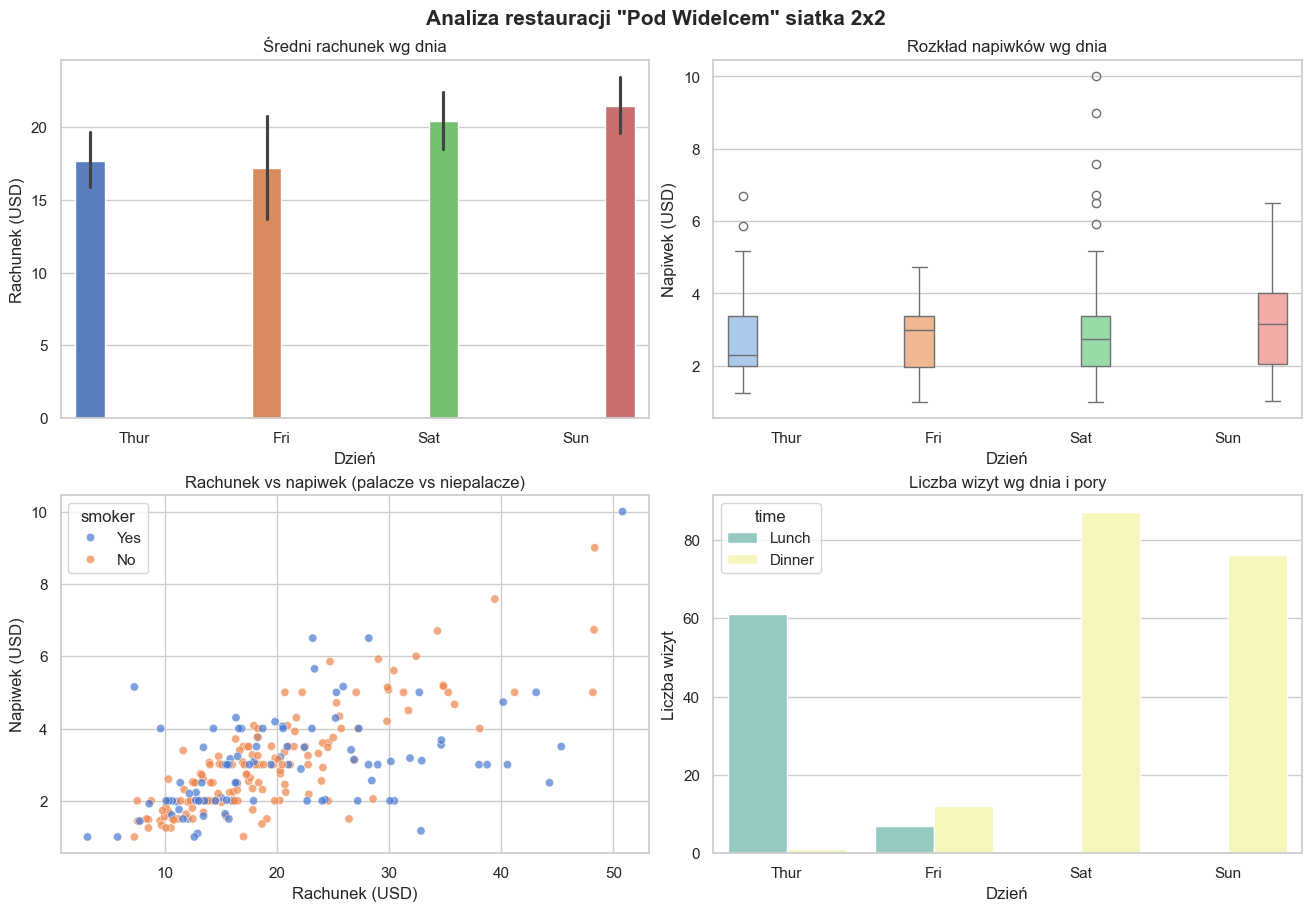

Zapisano: siatka_2x2.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True) 

# Panel [0, 0] barplot [cite: 208]
sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False,
            ax=axes[0, 0], palette='muted', errorbar=('ci', 95)) 
axes[0, 0].set_title('Średni rachunek wg dnia') 
axes[0, 0].set_xlabel('Dzień') 
axes[0, 0].set_ylabel('Rachunek (USD)') 

# Panel [0, 1] boxplot [cite: 216]
sns.boxplot(data=tips, x='day', y='tip', hue='day', legend=False,
            ax=axes[0, 1], palette='pastel') 
axes[0, 1].set_title('Rozkład napiwków wg dnia') 
axes[0, 1].set_xlabel('Dzień') 
axes[0, 1].set_ylabel('Napiwek (USD)') 

# Panel [1, 0] scatter [cite: 230]
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker',
                alpha=0.7, ax=axes[1, 0]) 
axes[1, 0].set_title('Rachunek vs napiwek (palacze vs niepalacze)') 
axes[1, 0].set_xlabel('Rachunek (USD)') 
axes[1, 0].set_ylabel('Napiwek (USD)') 

# Panel [1, 1] countplot [cite: 244]
sns.countplot(data=tips, x='day', hue='time', ax=axes[1, 1], palette='Set3') 
axes[1, 1].set_title('Liczba wizyt wg dnia i pory') 
axes[1, 1].set_xlabel('Dzień') 
axes[1, 1].set_ylabel('Liczba wizyt') 

fig.suptitle('Analiza restauracji "Pod Widelcem" siatka 2x2', fontsize=15, fontweight='bold') 
plt.savefig('siatka_2x2.png', dpi=150, bbox_inches='tight', facecolor='white') 
plt.show() 
plt.close() 
print("Zapisano: siatka_2x2.png") 

<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Student P1-105-07\AppData\Local\Temp\ipykernel_20624\1005260869.py:12: SyntaxWarning: invalid escape sequence '\$'
  ax_top.text(i, val + 20, f'\${val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')


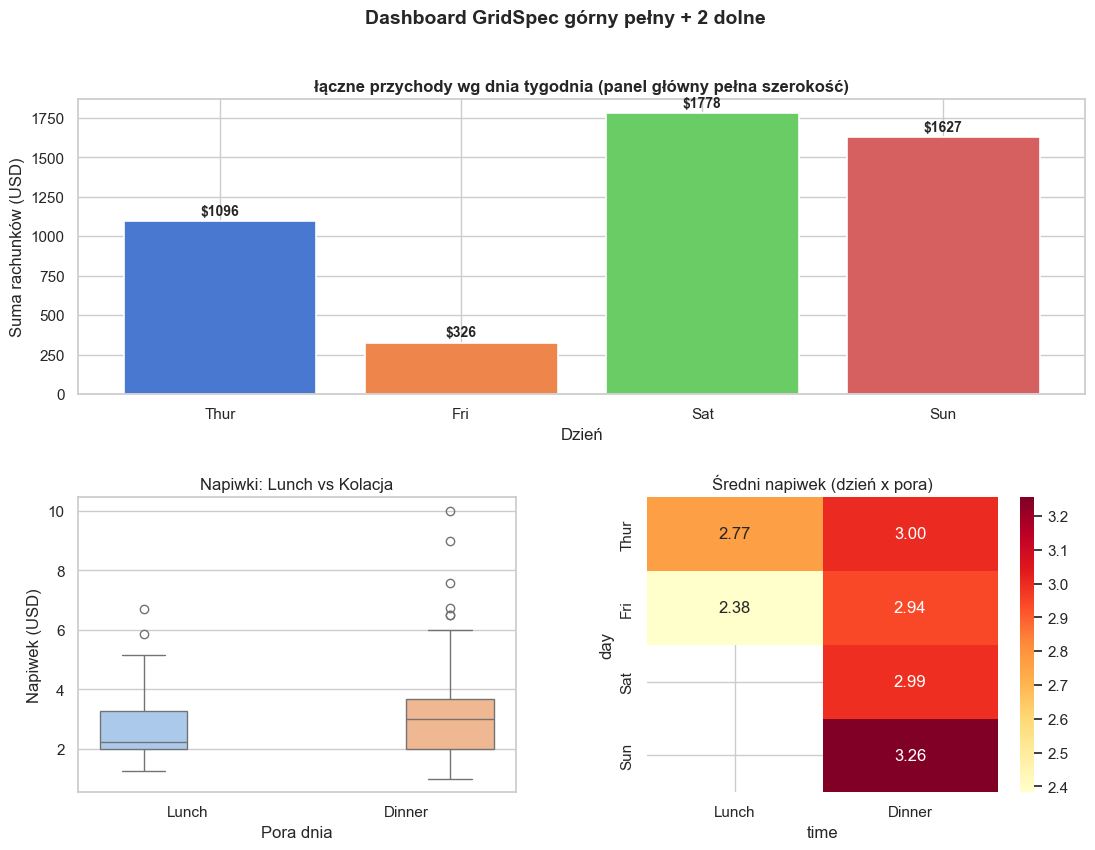

Zapisano: gridspec_dashboard.png


In [11]:
pivot = tips.pivot_table(values='tip', index='day', columns='time', aggfunc='mean', observed=True)

fig = plt.figure(figsize=(13, 9))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# Górny pełna szerokość
ax_top = fig.add_subplot(gs[0, :])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
ax_top.bar(tips_sum['day'].astype(str), tips_sum['total_bill'], color=sns.color_palette('muted')[:4], edgecolor='white', linewidth=1.2)

for i, val in enumerate(tips_sum['total_bill']):
    ax_top.text(i, val + 20, f'\${val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax_top.set_title('łączne przychody wg dnia tygodnia (panel główny pełna szerokość)', fontsize=12, fontweight='bold')
ax_top.set_xlabel('Dzień')
ax_top.set_ylabel('Suma rachunków (USD)')

# Dolny lewy boxplot
ax_bl = fig.add_subplot(gs[1, 0])
sns.boxplot(data=tips, x='time', y='tip', hue='time', legend=False, ax=ax_bl, palette='pastel')
ax_bl.set_title('Napiwki: Lunch vs Kolacja')
ax_bl.set_xlabel('Pora dnia')
ax_bl.set_ylabel('Napiwek (USD)')

# Dolny prawy heatmap
ax_br = fig.add_subplot(gs[1, 1])
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax_br)
ax_br.set_title('Średni napiwek (dzień x pora)')

fig.suptitle('Dashboard GridSpec górny pełny + 2 dolne', fontsize=14, fontweight='bold')
plt.savefig('gridspec_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: gridspec_dashboard.png")

C:\Users\Student P1-105-07\AppData\Local\Temp\ipykernel_20624\3176085554.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='tip', ax=axes[1, 0], palette='pastel')
C:\Users\Student P1-105-07\AppData\Local\Temp\ipykernel_20624\3176085554.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=tips, x='day', y='total_bill', ax=axes[1, 1], palette='pastel')


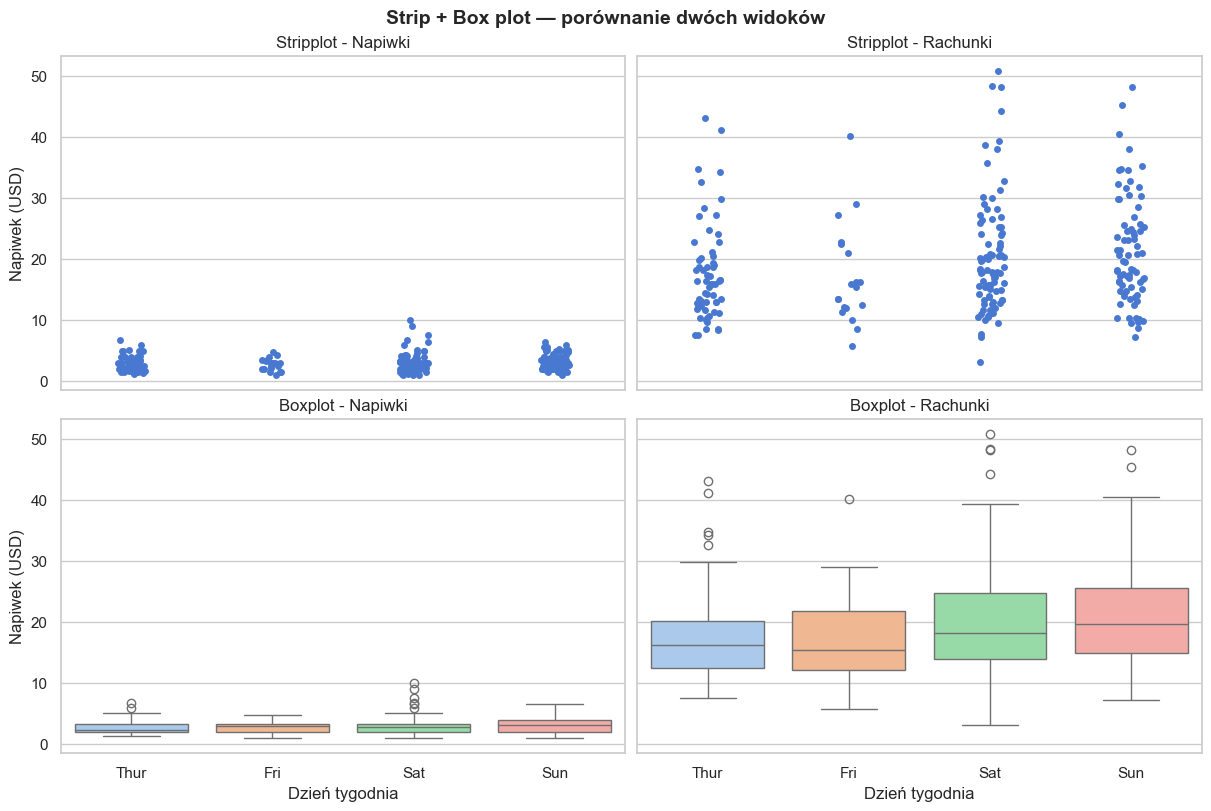

Zapisano: shared_axes.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex='col', sharey='row', constrained_layout=True)

# axes[0, 0] stripplot napiwki
sns.stripplot(data=tips, x='day', y='tip', ax=axes[0, 0], jitter=True)
axes[0, 0].set_title('Stripplot - Napiwki')
axes[0, 0].set_ylabel('Napiwek (USD)')

# axes[1, 0] boxplot napiwki
sns.boxplot(data=tips, x='day', y='tip', ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Boxplot - Napiwki')
axes[1, 0].set_xlabel('Dzień tygodnia')
axes[1, 0].set_ylabel('Napiwek (USD)')

# axes[0, 1] stripplot rachunki
sns.stripplot(data=tips, x='day', y='total_bill', ax=axes[0, 1], jitter=True)
axes[0, 1].set_title('Stripplot - Rachunki')
axes[0, 1].set_ylabel('Rachunek (USD)')

# axes[1, 1] boxplot rachunki
sns.boxplot(data=tips, x='day', y='total_bill', ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Boxplot - Rachunki')
axes[1, 1].set_xlabel('Dzień tygodnia')
axes[1, 1].set_ylabel('Rachunek (USD)')

fig.suptitle('Strip + Box plot — porównanie dwóch widoków', fontsize=14, fontweight='bold')
plt.savefig('shared_axes.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: shared_axes.png")

<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Student P1-105-07\AppData\Local\Temp\ipykernel_20624\2351797073.py:10: SyntaxWarning: invalid escape sequence '\$'
  ax1.text(i, val + 20, f'\${val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')


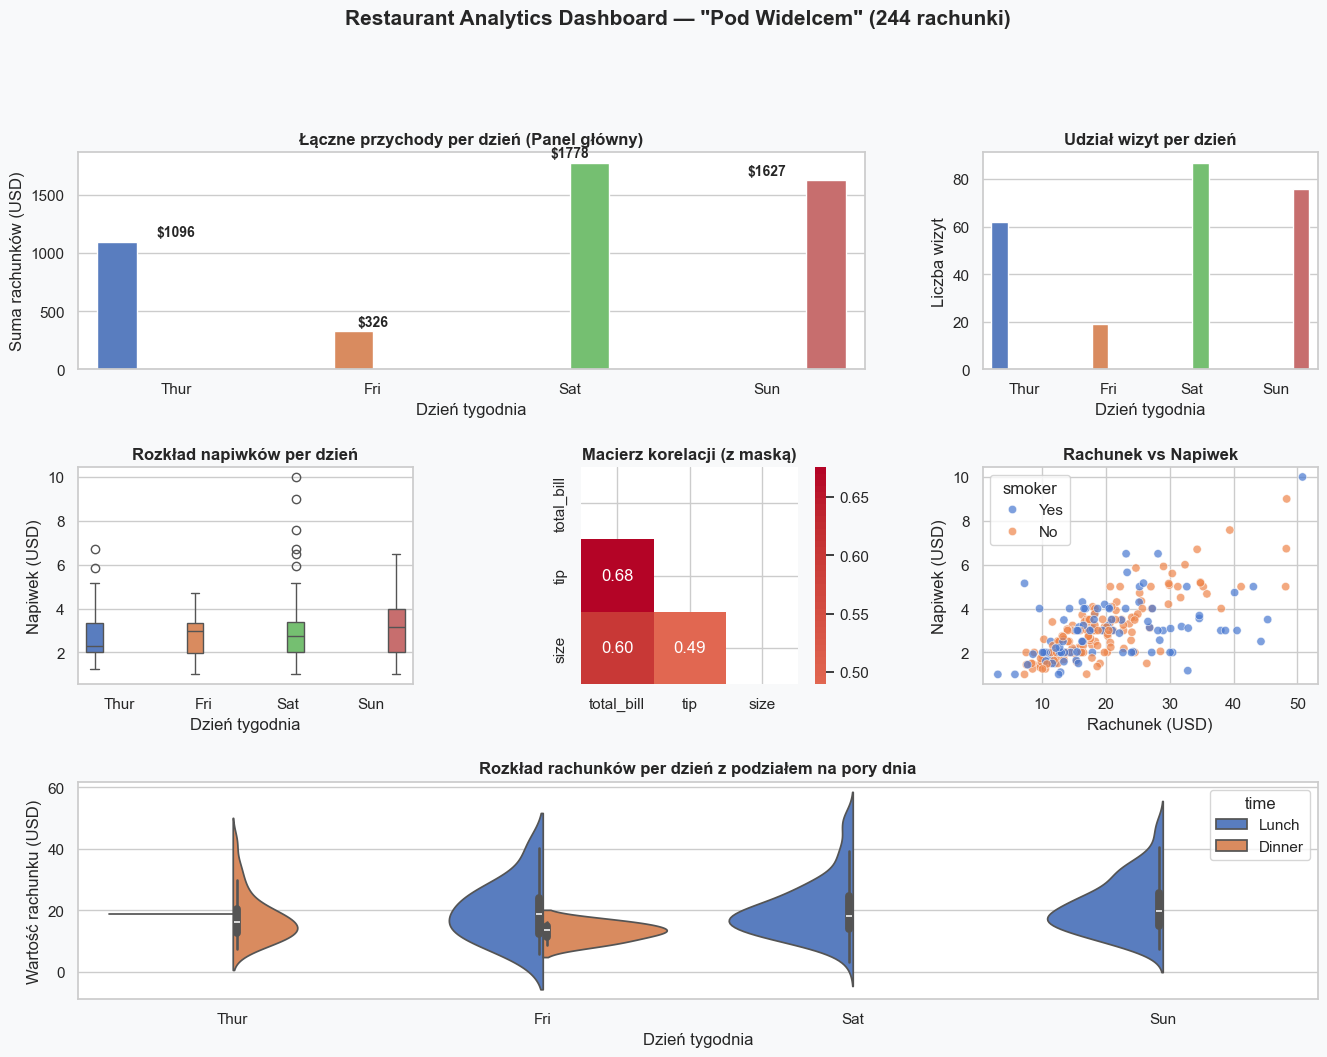

Zapisano: dashboard_pod_widelcem.png


In [13]:
fig = plt.figure(figsize=(16, 11))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

# === PANEL 1 (KPI główny): łączne przychody per dzień (gs[0, :2]) ===
ax1 = fig.add_subplot(gs[0, :2])
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False, ax=ax1, palette='muted')
for i, val in enumerate(tips_sum['total_bill']):
    ax1.text(i, val + 20, f'\${val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_title('Łączne przychody per dzień (Panel główny)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Dzień tygodnia')
ax1.set_ylabel('Suma rachunków (USD)')

# === PANEL 2: udział wizyt per dzień (gs[0, 2]) ===
ax2 = fig.add_subplot(gs[0, 2])
sns.countplot(data=tips, x='day', hue='day', legend=False, ax=ax2, palette='muted')
ax2.set_title('Udział wizyt per dzień', fontsize=12, fontweight='bold')
ax2.set_xlabel('Dzień tygodnia')
ax2.set_ylabel('Liczba wizyt')

# === PANEL 3: rozkład napiwków (gs[1, 0]) ===
ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=tips, x='day', y='tip', hue='day', legend=False, ax=ax3, palette='muted')
ax3.set_title('Rozkład napiwków per dzień', fontsize=12, fontweight='bold')
ax3.set_xlabel('Dzień tygodnia')
ax3.set_ylabel('Napiwek (USD)')

# === PANEL 4: heatmap korelacji (gs[1, 1]) ===
ax4 = fig.add_subplot(gs[1, 1])
corr = tips.select_dtypes('number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, mask=mask, ax=ax4, square=True)
ax4.set_title('Macierz korelacji (z maską)', fontsize=12, fontweight='bold')

# === PANEL 5: scatter (gs[1, 2]) ===
ax5 = fig.add_subplot(gs[1, 2])
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', ax=ax5, alpha=0.7)
ax5.set_title('Rachunek vs Napiwek', fontsize=12, fontweight='bold')
ax5.set_xlabel('Rachunek (USD)')
ax5.set_ylabel('Napiwek (USD)')

# === PANEL 6 (sumaryczny): rozkład rachunków (gs[2, :]) ===
ax6 = fig.add_subplot(gs[2, :])
sns.violinplot(data=tips, x='day', y='total_bill', hue='time', split=True, ax=ax6, palette='muted')
ax6.set_title('Rozkład rachunków per dzień z podziałem na pory dnia', fontsize=12, fontweight='bold')
ax6.set_xlabel('Dzień tygodnia')
ax6.set_ylabel('Wartość rachunku (USD)')

fig.suptitle('Restaurant Analytics Dashboard — "Pod Widelcem" (244 rachunki)', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('dashboard_pod_widelcem.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: dashboard_pod_widelcem.png")

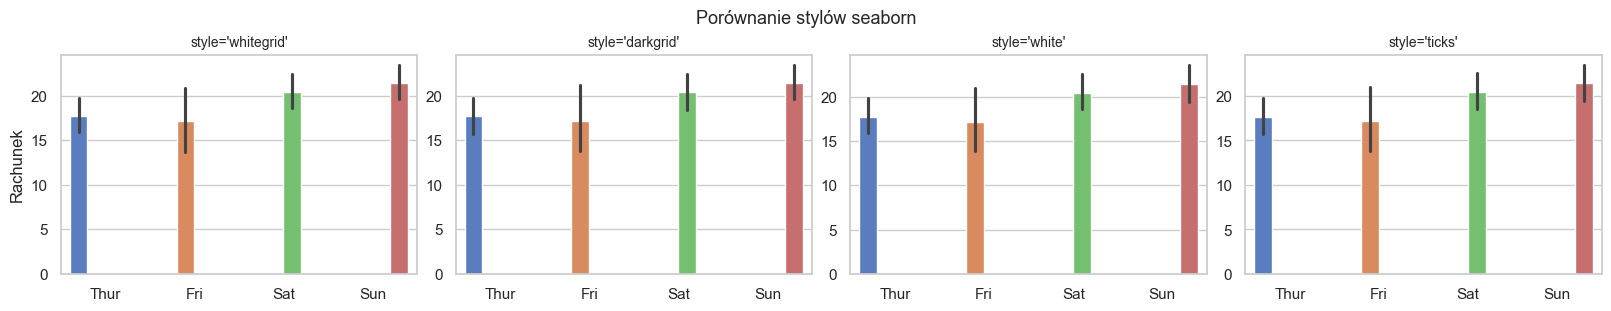

Zapisano: porownanie_stylow.png


In [14]:
styles = ['whitegrid', 'darkgrid', 'white', 'ticks']
fig, axes = plt.subplots(1, 4, figsize=(16, 3), constrained_layout=True)
for ax, style in zip(axes, styles):
    with sns.axes_style(style):
        sns.barplot(data=tips, x='day', y='total_bill', hue='day', legend=False, ax=ax, palette='muted')
        ax.set_title(f"style='{style}'", fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Rachunek' if ax is axes[0] else '')
fig.suptitle('Porównanie stylów seaborn', fontsize=13)
plt.savefig('porownanie_stylow.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: porownanie_stylow.png")

<>:12: SyntaxWarning: invalid escape sequence '\$'
<>:12: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Student P1-105-07\AppData\Local\Temp\ipykernel_20624\3797056187.py:12: SyntaxWarning: invalid escape sequence '\$'
  f'Szczyt: \${max_val:.0f} ({max_day})',


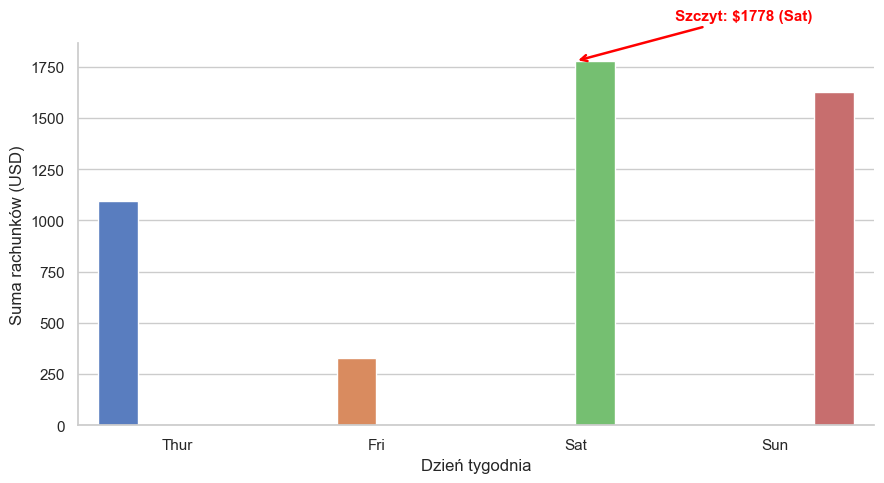

Zapisano: szczyt_przychodow.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
tips_sum = tips.groupby('day', observed=True)['total_bill'].sum().reset_index()
sns.barplot(data=tips_sum, x='day', y='total_bill', hue='day', legend=False, ax=ax, palette='muted')

# Znajdź szczyt
max_idx = tips_sum['total_bill'].idxmax()
max_day = tips_sum.loc[max_idx, 'day']
max_val = tips_sum.loc[max_idx, 'total_bill']

# Adnotacja ze strzałką
ax.annotate(
    f'Szczyt: \${max_val:.0f} ({max_day})',
    xy=(max_idx, max_val),
    xytext=(max_idx + 0.5, max_val + 200),
    arrowprops=dict(arrowstyle='->', color='red', lw=1.8),
    fontsize=11, color='red', fontweight='bold',
)

ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Suma rachunków (USD)')
sns.despine()
plt.tight_layout()
plt.savefig('szczyt_przychodow.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()
print("Zapisano: szczyt_przychodow.png")